# Classical Shadows on a Cluster State

This notebook is a companion example for the Qurrium paper's classical-shadow
demonstrations. Using `qurrium`, we:

1. Build a 6-qubit cluster state with open boundary condition.
2. Measure it with `ShadowUnveil` using a classical-shadow protocol (randomized single-qubit Pauli measurement bases).
3. Estimate three properties with the measurement outcomes: **mutual information** between two halves of the chain, **observable** expectation values on a subsystem, and state **overlap**.

## Setup

In [2]:
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
from qurry import ShadowUnveil
import time
from qiskit import QuantumCircuit
from qurry.recipe import cluster as Cluster, ghz as GHZ, trivial_paramagnet as TrivialParamagnet
from qurry.qurries.classical_shadow.analysis import SUAnalysis
from qiskit_aer import AerSimulator

In [3]:
from qurry import __version__
print("| Using qurrium version:", __version__)

| Using qurrium version: 1.0.0.dev5


## The measurement manager: `ShadowUnveil`

`ShadowUnveil` is qurry's entry point for classical-shadow experiments: it runs
circuits, and stores every experiment and its later analyses.


In [4]:
experiment_shadow = ShadowUnveil()

## Building the cluster state circuit

`qurry.recipe.cluster(num_qubits, border_cond=...)` builds a cluster state:
a Hadamard on every qubit, followed by `CZ` gates entangling neighbors.

Note that `border_cond` **defaults to `"period"`** (a ring, with an extra `CZ`
wrapping qubit `n-1` back to qubit `0`). Here we pass `border_cond='open'`
deliberately, to get a linear chain instead.


In [5]:
n = 6
cluster = Cluster(n, border_cond='open')


In [6]:
cluster.draw()


┌───┐      
q_0: ┤ H ├─■────
     ├───┤ │    
q_1: ┤ H ├─■──■─
     ├───┤    │ 
q_2: ┤ H ├─■──■─
     ├───┤ │    
q_3: ┤ H ├─■──■─
     ├───┤    │ 
q_4: ┤ H ├─■──■─
     ├───┤ │    
q_5: ┤ H ├─■────
     └───┘

## Choosing a measurement basis

A classical shadow is built from many snapshots, each measured in a randomly
chosen single-qubit basis per qubit. `make_evenly_basis(num_qubits, duplication)`
gives us a basis set deterministically: it enumerates **all** `3**num_qubits`
basis combinations exactly `duplication` times each, rather than sampling
randomly. This guarantees even coverage of every basis combination, which is
convenient for a small, reproducible example like this one.


In [7]:
from qurry.process.classical_shadow import make_evenly_basis
even_basis = make_evenly_basis(num_qubits=n, duplication=1)

## Running the shadow measurement

`cluster_shadow.measure(...)` runs one circuit per snapshot in `cluster_basis` and returns the resulting experiment object directly (no separate lookup step needed). 

The default backend is `AerSimulator` imported from `qiskit_aer`. To change the backend, one can use the argument `backend`.

In [42]:
from qiskit_ibm_runtime.fake_provider import FakeBerlin
SHOTS=500
backend=FakeBerlin()
cluster_exp = experiment_shadow.measure(
    cluster,
    random_basis=even_basis,
    shots=SHOTS,
    tags=('cluster',),
    run_args={'seed_simulator': 42},
    backend=AerSimulator.from_backend(backend) 
    #Uncomment the line above if one wants to use noisy backend simulator
)  


## Analysis

With the shadow measurement in hand, we look at it three ways: the mutual
information between two halves of the chain, expectation values of chosen
observables on a subsystem, and (to be added) the overlap with a reference
state.


### 1. Mutual information based on Second-order Renyi entropy

We call `.analyze(...)` three times, on subsystem A (`[0,1]`), subsystem B (`[2,3]`), and the subsystem A+B (`[0,1,2,3]`), then combine `results["purity"]["entropy"]` from each via `I(A:B) = S_A + S_B - S_AB`. For noiseless simulation, the result is close to $2$. This cell may take a few  minutes to execute.

In [43]:
subA = cluster_exp.analyze(selected_qubits=[0, 1])
subB = cluster_exp.analyze(selected_qubits=[2, 3])
full = cluster_exp.analyze(selected_qubits=[0,1,2,3])


In [44]:
sA = subA.results['purity'].entropy
sB = subB.results['purity'].entropy
sAB = full.results['purity'].entropy
mutual = sA + sB - sAB
print('The entropy for each subsystem is\n' f"sA={sA}\nsB={sB}\n")
print('The entropy for the full system is' f" sAB={sAB}\n")
print('The mutual information is' f" sA+sB-sAB={mutual}\n")



The entropy for each subsystem is
sA=1.0688052817695561
sB=1.9997964391223346

The entropy for the full system is sAB=1.1886132101802704

The mutual information is sA+sB-sAB=1.8799885107116203



### 2. Observables

Here we instead pass `given_operators` to `.analyze(...)` to get shadow-estimated
expectation values for specific operators on a 3-qubit subsystem, and skip the
(unneeded here) purity/entropy computation with `trace_method="skip_trace"`.


In [45]:
# First, we define the matrices for the operators.
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])
ops = [
    np.kron(I, np.kron(Z, X)),
    np.kron(Z, np.kron(X, Z)),
    np.kron(I, np.kron(X, Z)),
]


In [46]:
# Second, specify the operators into the argument.
cluster_results = cluster_exp.analyze(
    selected_qubits=[0, 1, 2], given_operators=ops, trace_method="skip_trace"
)


In the returned object, `results_fields()` lists every available `(result_block, field)` pair on the
analysis. From there, values can be pulled out attribute-style
(`cluster_results.results['estimation'].estimate_of_given_operators`).

In [47]:
cluster_results.results_fields()


(('basic', 'average_snapshots_rho_list'),
 ('basic', 'classical_registers_actually'),
 ('basic', 'taking_time'),
 ('basic', 'rho_method'),
 ('basic', 'random_basis_data'),
 ('basic', 'mean_of_rho'),
 ('basic', 'use_projecter'),
 ('estimation', 'estimate_of_given_operators'),
 ('estimation', 'corresponding_rhos'),
 ('estimation', 'all_candidates_of_estimate'),
 ('estimation', 'trace_with_mean_rho_of_given_operators'),
 ('estimation', 'accuracy_prob_comp_delta'),
 ('estimation', 'num_of_estimators_k'),
 ('estimation', 'accuracy_predict_epsilon'),
 ('estimation', 'maximum_shadow_norm'),
 ('estimation', 'epsilon_upperbound'),
 ('estimation', 'shadow_norm_upperbound'),
 ('estimation', 'taking_time'),
 ('estimation', 'estimate_trace_method'))

In [48]:
results = cluster_results.results
display(Markdown('The estimated expectation values for $X_0Z_1, Z_0X_1Z_2, Z_0X_1$ are:'))
results['estimation'].trace_with_mean_rho_of_given_operators


The estimated expectation values for $X_0Z_1, Z_0X_1Z_2, Z_0X_1$ are:

[np.complex128(0.9523456790123446+0j),
 np.complex128(0.9343703703703701+0j),
 np.complex128(0.0049382716049384545+0j)]

### 3. Overlap
#### The overlap between the cluster with periodic boundary condition and three reference states: the all-zero state $|0\rangle^{\otimes n}$, the all-plus state $|+\rangle^{\otimes n}$, and the Greenberger--Horne--Zeilinger (GHZ) state $|\mathrm{GHZ}\rangle = \frac{1}{\sqrt{2}} \left(|0\rangle^{\otimes n} + |1\rangle^{\otimes n}\right)$.

First, we show how to estimate the overlap between the shadow-estimated state and an analytical reference state, e.g. `f_{sigma}=Tr(rho @ sigma)`.

`ref_analytical_density_matrix(n, k, kind)` builds the *analytic* $k$-qubit reference density matrix $\sigma_k$ for each `kind`:

- `'all-zero'` and `'all-plus'` are already product states, so their $k$-qubit reduced state is just the $k$-qubit version of that product state directly — no real partial trace is needed.
- `'ghz'` is genuinely entangled across all $n$ qubits, so we build the full $n$-qubit GHZ vector and *partially trace it down* to $k$ qubits via the `reshape` / `psi_mat.T @ psi_mat.conj()` trick. Because GHZ is symmetric under any permutation of its qubits, tracing out *any* $n-k$ qubits gives the same reduced state — so it's fine that this traces out the *last* $n-k$ qubits, even though we'll select the *first* $k$ qubits of the cluster state below.

In [49]:
def ref_analytical_density_matrix(n,k, kind):
    if kind == 'ghz':
        psi = np.zeros(2**n, dtype='complex128')
        psi[0] = psi[-1] = 1/np.sqrt(2)
        psi_mat = psi.reshape(2**(n - k), 2**k)
        return psi_mat.T @ psi_mat.conj()
    elif kind == 'all-plus':
        psi = np.ones(2**k, dtype='complex128') / np.sqrt(2**k)
        return np.outer(psi, psi.conj())
    elif kind == 'all-zero':
        psi = np.zeros(2**k, dtype='complex128')
        psi[0] = 1.0
        return np.outer(psi, psi.conj())

Overlap is computed against a **periodic** cluster state (`border_cond='period'`, a ring) rather than the open chain used earlier, so we build `cluster_p` and measure it as its own experiment `cluster_p_exp`, reusing the same `even_basis` / `SHOTS` / seed as the rest of the notebook for consistency.

In [54]:
cluster_p = Cluster(n, border_cond='period')
cluster_p_exp = experiment_shadow.measure(
    cluster_p,
    random_basis=even_basis,
    shots=SHOTS,
    tags=('cluster_p',),
    run_args={'seed_simulator': 41}
)  


`compute_trace_linear` wraps `ref_analytical_density_matrix` and returns $\mathrm{Tr}(\rho_k\,\sigma_k)$ for a given reference `kind`. In the loop below, for each subsystem size $k=1,\dots,n$ we take the shadow-estimated reduced density matrix of the periodic cluster state on qubits $[0, k)$ (`mean_of_rho`, via `trace_method="skip_trace"` since purity/entropy aren't needed here) and compute its overlap with all three analytic references.

Because $\sigma_k$ is a *known, fixed* operator, $\mathrm{Tr}(\rho_k \sigma_k)$ is a **linear functional** of $\rho_k$ — exactly like the observable expectation values in the previous section — so it can be estimated directly from the averaged shadow `mean_of_rho`.

In [55]:
def compute_trace_linear(clusterrho, matchstate, n, k):
    refrho=ref_analytical_density_matrix(n,k,matchstate)
    return np.trace(clusterrho @ refrho)

In [56]:
overlap_ghz = []
overlap_zero = []
overlap_plus = []
for k in range(1, n + 1):
    cluster_p_results = cluster_p_exp.analyze(
        selected_qubits=range(k), trace_method="skip_trace")
    meanrho_p = np.array(cluster_p_results.export()['results']['basic']['mean_of_rho'], dtype='complex128')
    overlap_ghz.append(compute_trace_linear(meanrho_p, 'ghz', n, k).real)
    overlap_zero.append(compute_trace_linear(meanrho_p, 'all-zero', n, k).real)
    overlap_plus.append(compute_trace_linear(meanrho_p, 'all-plus', n, k).real)
    print(k, overlap_ghz[-1], overlap_zero[-1], overlap_plus[-1])

1 0.4999999999999998 0.5014485596707823 0.49759670781892984
2 0.25122222222222196 0.25198765432098763 0.24924279835390922
3 0.1265987654320987 0.1274732510288066 0.12760288065843606
4 0.06315123456790123 0.06343930041152267 0.061292181069958776
5 0.03266203703703699 0.031175411522633704 0.06359825102880645
6 0.033185956790123365 0.017001800411522588 0.0629089506172838


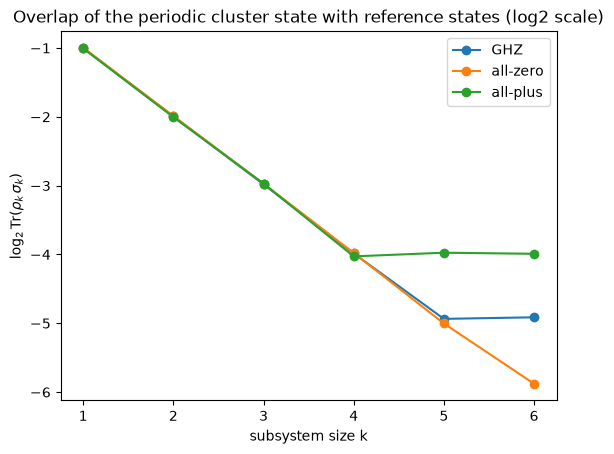

In [57]:
ks = list(range(1, n + 1))
plt.plot(ks, np.log2(overlap_ghz), marker='o', label='GHZ')
plt.plot(ks, np.log2(overlap_zero), marker='o', label='all-zero')
plt.plot(ks, np.log2(overlap_plus), marker='o', label='all-plus')
plt.xlabel('subsystem size k')
plt.ylabel(r'$\log_2 \mathrm{Tr}(\rho_k\,\sigma_k)$')
plt.title('Overlap of the periodic cluster state with reference states (log2 scale)')
plt.legend()
plt.show()

### Overlap estimator

The approach above only works because we know $\sigma_k$ analytically ahead of time. If instead we only have *another experiment's* classical shadow of the reference state, then we apply the overlap estimator that takes the *two independent* measurement outcomes using the same Pauli measurement setting. 

We prepare and measure three reference states directly, using classical shadows exactly like the cluster state: `GHZ(n)` (the GHZ state), `TrivialParamagnet(n)` (an all-`H` circuit, i.e. the all-plus product state $|+\rangle^{\otimes n}$), and a bare `QuantumCircuit(n)` (no gates, i.e. the all-zero product state $|0\rangle^{\otimes n}$). In this example, we use an evenly distributed basis set. One can choose any other random sets of Pauli unitaries.

Each measurement is performed with the **same** `Pauli measurement setting` as the cluster state.

In [62]:
ghz = GHZ(n)
plus = TrivialParamagnet(n)
zero = QuantumCircuit(n)
SHOTS=3000
ghzexp = experiment_shadow.measure(ghz, random_basis=even_basis, shots=SHOTS, tags=('ghz',),run_args={'seed_simulator': 41})
plusexp = experiment_shadow.measure(plus, random_basis=even_basis, shots=SHOTS, tags=('para',),run_args={'seed_simulator': 41})
zeroexp = experiment_shadow.measure(zero,random_basis=even_basis, shots=SHOTS, tags=('init',),run_args={'seed_simulator': 41})


With `use_projecter=True`, `analyze()` computes per-snapshot projector matrices and stores them in `average_snapshots_rho_list`. The reference experiments (without `use_projecter`) store the per-snapshot shadow density matrices the same way. `calculate_overlap(match, projecter)` then reads both lists and computes the average of `Tr(projector_c[i] · rho_m[i])` over all snapshots.

In [64]:
def calculate_overlap(match: SUAnalysis, projecter: SUAnalysis):
    projector_c_list = np.array(
        projecter.results["basic"].average_snapshots_rho_list, dtype="complex128"
    )
    rho_m_list = np.array(
        match.results["basic"].average_snapshots_rho_list, dtype="complex128"
    )

    trclusterrho = np.einsum("nij,nji->n", projector_c_list, rho_m_list)
    return trclusterrho.sum() / len(projector_c_list)

The loop below repeats this for $k=1,\dots,n$ against all three references, first calling `.analyze(..., trace_method="skip_trace")` on each reference experiment restricted to the same $k$ qubits.

In [65]:
nloverlap_ghz = []
nloverlap_zero = []
nloverlap_plus = []

for k in range(1, n + 1):
    zero_est = zeroexp.analyze(
        selected_qubits=np.arange(k).tolist(), trace_method="skip_trace"
    )
    plus_est = plusexp.analyze(
        selected_qubits=np.arange(k).tolist(), trace_method="skip_trace"
    )
    ghz_est = ghzexp.analyze(
        selected_qubits=np.arange(k).tolist(), trace_method="skip_trace"
    )

    cluster_est = cluster_p_exp.analyze(
        selected_qubits=np.arange(k).tolist(),
        trace_method="skip_trace",
        use_projecter=True,
    )

    nloverlap_zero.append(calculate_overlap(zero_est, cluster_est))
    nloverlap_plus.append(calculate_overlap(plus_est, cluster_est))
    nloverlap_ghz.append(calculate_overlap(ghz_est, cluster_est))


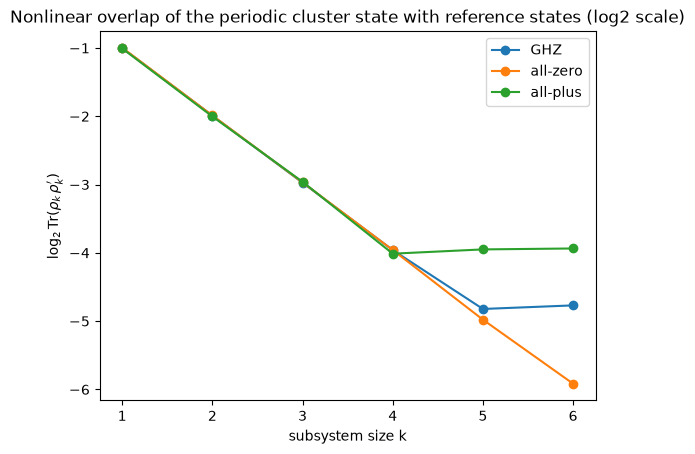

In [66]:
ks = list(range(1, n + 1))
plt.plot(ks, np.log2(nloverlap_ghz).real, marker='o', label='GHZ')
plt.plot(ks, np.log2(nloverlap_zero).real, marker='o', label='all-zero')
plt.plot(ks, np.log2(nloverlap_plus).real, marker='o', label='all-plus')
plt.xlabel('subsystem size k')
plt.ylabel(r'$\log_2 \mathrm{Tr}(\rho_k\,\rho^{\prime}_k)$')
plt.title('Nonlinear overlap of the periodic cluster state with reference states (log2 scale)')
plt.legend()
plt.show()

**AI usage disclosure**
AI assistance was used for code and markdown explanations, under author guidance, and was verified by the authors.